In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (13, 5)

ROOT = Path.cwd().parent
firms = pd.read_csv(
    ROOT / "data" / "processed" / "firms_kalimantan_2012_2026.csv",
    parse_dates=["tanggal"],
    low_memory=False,
)
sipongi = pd.read_csv(ROOT / "data" / "processed" / "luas_kalimantan_provinsi.csv")

print("FIRMS :", firms.shape)
print("SiPongi:", sipongi.shape)
firms.head(3)

FIRMS : (1488643, 19)
SiPongi: (75, 6)


,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight,type,tanggal,tahun,bulan,musim
0,-3.88574,115.10657,338.97,0.42,0.37,2012-01-20,538,N,VIIRS,n,2,295.79,5.82,D,0.0,2012-01-20,2012,1,basah
1,-3.62912,115.49331,356.33,0.40,0.37,2012-01-20,538,N,VIIRS,n,2,298.85,43.82,D,0.0,2012-01-20,2012,1,basah
2,-2.18322,115.98127,331.25,0.39,0.36,2012-01-20,539,N,VIIRS,n,2,289.68,3.12,D,0.0,2012-01-20,2012,1,basah


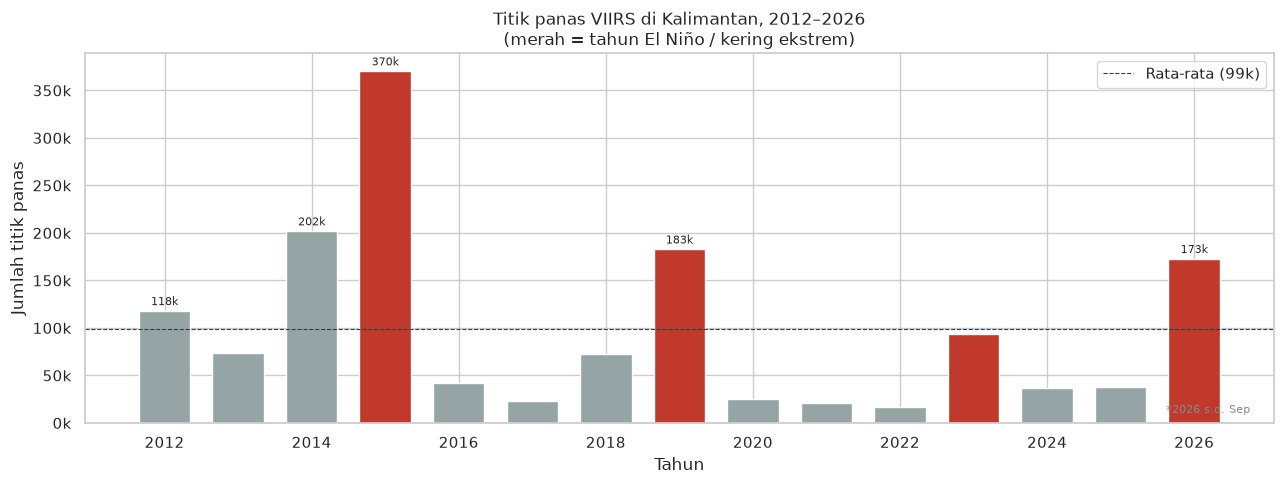

In [2]:
# Titik panas per tahun
per_tahun = firms.groupby("tahun").size().reset_index(name="titik_panas")

# Warnai tahun El Niño
el_nino = {2015, 2019, 2023, 2026}
warna = ["#c0392b" if t in el_nino else "#95a5a6" for t in per_tahun["tahun"]]

fig, ax = plt.subplots()
bars = ax.bar(per_tahun["tahun"], per_tahun["titik_panas"], color=warna, width=0.7)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
ax.set_xlabel("Tahun")
ax.set_ylabel("Jumlah titik panas")
ax.set_title("Titik panas VIIRS di Kalimantan, 2012–2026\n(merah = tahun El Niño / kering ekstrem)")
ax.axhline(per_tahun["titik_panas"].mean(), color="#2c3e50", linestyle="--",
           linewidth=0.8, label=f"Rata-rata ({per_tahun['titik_panas'].mean()/1000:.0f}k)")

# Beri label di atas bar yang melebihi rata-rata
for bar, val, tahun in zip(bars, per_tahun["titik_panas"], per_tahun["tahun"]):
    if val > per_tahun["titik_panas"].mean():
        ax.text(bar.get_x() + bar.get_width()/2, val + 3000,
                f"{val/1000:.0f}k", ha="center", va="bottom", fontsize=8)

ax.legend()
ax.annotate("*2026 s.d. Sep", xy=(0.98, 0.02), xycoords="axes fraction",
            ha="right", va="bottom", fontsize=8, color="#7f8c8d")
plt.tight_layout()
plt.show()

 tahun  titik_panas   luas_ha  ha_per_titik
  2012       118213 374122.00          3.16
  2013        73452  88836.00          1.21
  2014       202166 641129.00          3.17
  2015       370497 957725.17          2.58
  2016        41750  62898.56          1.51
  2017        23277  18260.09          0.78
  2018        72148 243013.50          3.37
  2019       183026 684599.00          3.74
  2020        24795  26286.00          1.06
  2021        20934  37575.00          1.79
  2022        17144  24562.00          1.43
  2023        93804 508430.22          5.42
  2024        36464  65608.11          1.80
  2025        37977  55717.27          1.47


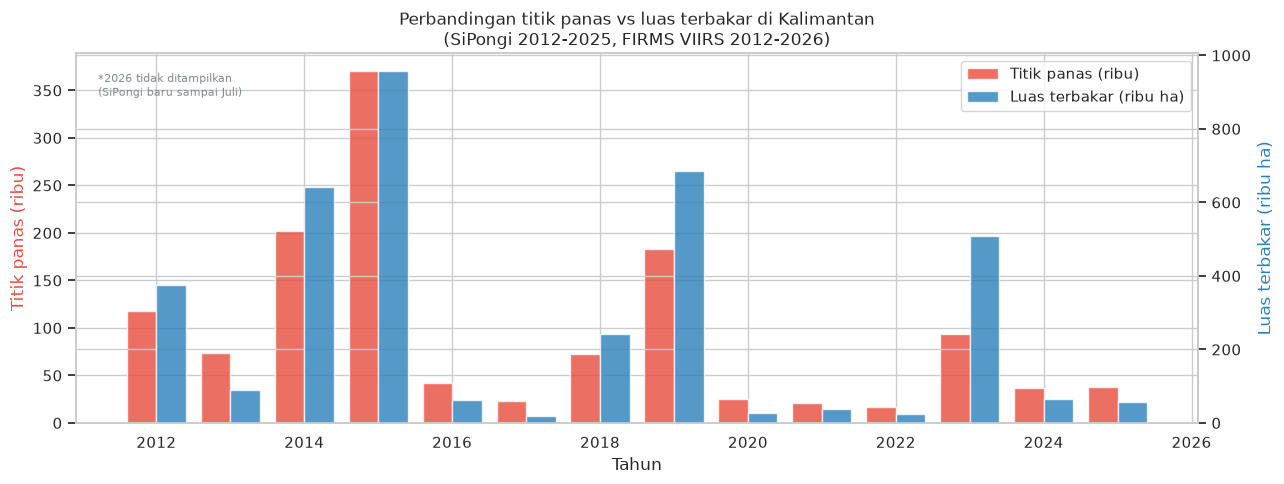

In [3]:
# Gabungkan dua sumber
per_tahun_prov = (
    firms.groupby(["tahun", "musim"])
    .size()
    .reset_index(name="titik_panas")
)

# Total titik panas per tahun, dan total luas terbakar Kalimantan per tahun
titik = firms.groupby("tahun").size().reset_index(name="titik_panas")

luas = (
    sipongi[sipongi["tahun_parsial"] == False]
    .groupby("tahun")["luas_ha"]
    .sum()
    .reset_index()
)

gabung = titik.merge(luas, on="tahun", how="inner")
gabung["ha_per_titik"] = gabung["luas_ha"] / gabung["titik_panas"]

print(gabung[["tahun", "titik_panas", "luas_ha", "ha_per_titik"]].round(2).to_string(index=False))

fig, ax1 = plt.subplots()
ax2 = ax1.twinx()

warna_titik = "#e74c3c"
warna_luas = "#2980b9"

ax1.bar(gabung["tahun"] - 0.2, gabung["titik_panas"] / 1000,
        width=0.4, color=warna_titik, alpha=0.8, label="Titik panas (ribu)")
ax2.bar(gabung["tahun"] + 0.2, gabung["luas_ha"] / 1000,
        width=0.4, color=warna_luas, alpha=0.8, label="Luas terbakar (ribu ha)")

ax1.set_ylabel("Titik panas (ribu)", color=warna_titik)
ax2.set_ylabel("Luas terbakar (ribu ha)", color=warna_luas)
ax1.set_xlabel("Tahun")
ax1.set_title("Perbandingan titik panas vs luas terbakar di Kalimantan\n(SiPongi 2012-2025, FIRMS VIIRS 2012-2026)")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

ax1.annotate("*2026 tidak ditampilkan\n(SiPongi baru sampai Juli)",
             xy=(0.02, 0.95), xycoords="axes fraction",
             fontsize=8, color="#7f8c8d", va="top")

plt.tight_layout()
plt.show()

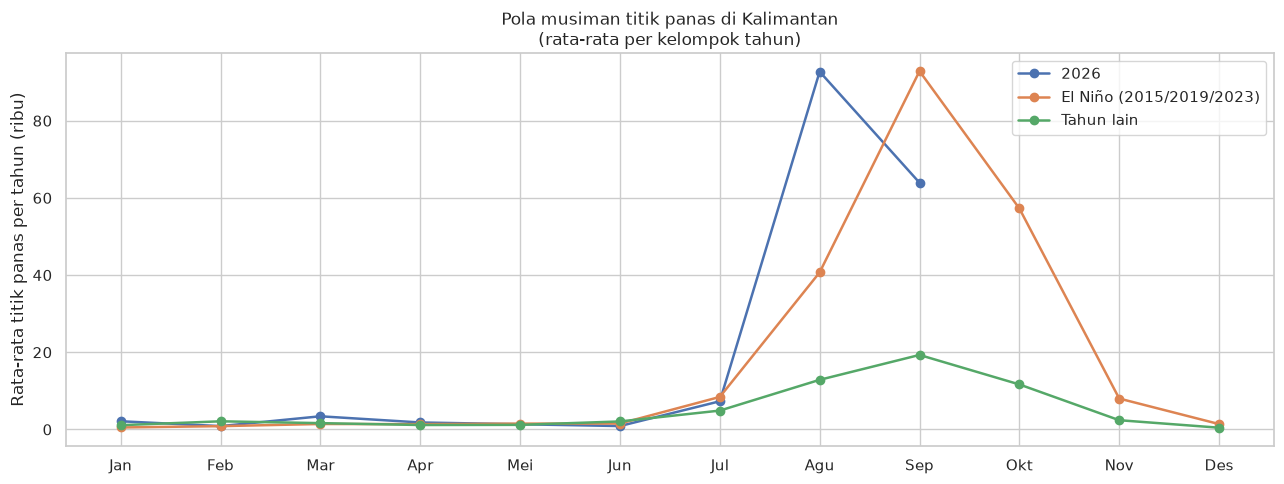

In [4]:
# Distribusi titik panas per bulan, bandingkan tahun El Niño vs normal
firms["kategori"] = firms["tahun"].map(
    lambda t: "El Niño (2015/2019/2023)" if t in {2015, 2019, 2023}
    else ("2026" if t == 2026 else "Tahun lain")
)

per_bulan = (
    firms.groupby(["bulan", "kategori"])
    .size()
    .reset_index(name="titik_panas")
)

# Normalkan ke rata-rata per tahun supaya perbandingan adil
n_tahun = {"El Niño (2015/2019/2023)": 3, "2026": 1, "Tahun lain": 11}
per_bulan["per_tahun"] = per_bulan.apply(
    lambda r: r["titik_panas"] / n_tahun[r["kategori"]], axis=1
)

nama_bulan = ["Jan","Feb","Mar","Apr","Mei","Jun",
              "Jul","Agu","Sep","Okt","Nov","Des"]

fig, ax = plt.subplots()
for kat, grp in per_bulan.groupby("kategori"):
    grp = grp.sort_values("bulan")
    ax.plot(grp["bulan"], grp["per_tahun"] / 1000,
            marker="o", label=kat, linewidth=1.8)

ax.set_xticks(range(1, 13))
ax.set_xticklabels(nama_bulan)
ax.set_ylabel("Rata-rata titik panas per tahun (ribu)")
ax.set_title("Pola musiman titik panas di Kalimantan\n(rata-rata per kelompok tahun)")
ax.legend()
plt.tight_layout()
plt.show()

Provinsi ditemukan: ['Kalimantan Barat', 'Kalimantan Selatan', 'Kalimantan Tengah', 'Kalimantan Timur', 'Kalimantan Utara']


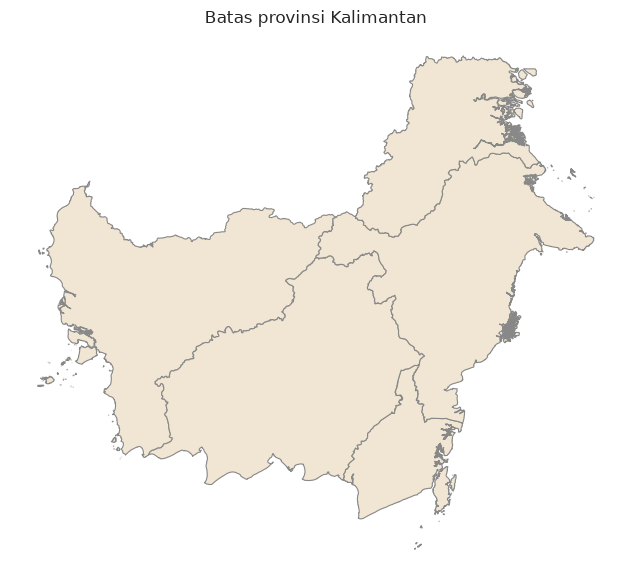

In [5]:
import geopandas as gpd

ROOT = Path.cwd().parent
shp = ROOT / "data" / "raw" / "shapefile" / "gadm41_IDN_1.shp"
indonesia = gpd.read_file(shp)

# Filter Kalimantan
nama_kalimantan = [
    "Kalimantan Barat", "Kalimantan Tengah",
    "Kalimantan Selatan", "Kalimantan Timur", "Kalimantan Utara"
]
kalimantan = indonesia[indonesia["NAME_1"].isin(nama_kalimantan)].copy()

print(f"Provinsi ditemukan: {kalimantan['NAME_1'].tolist()}")
kalimantan.plot(figsize=(8, 6), color="#f0e6d3", edgecolor="#888", linewidth=0.8)
plt.title("Batas provinsi Kalimantan")
plt.axis("off")
plt.tight_layout()
plt.show()

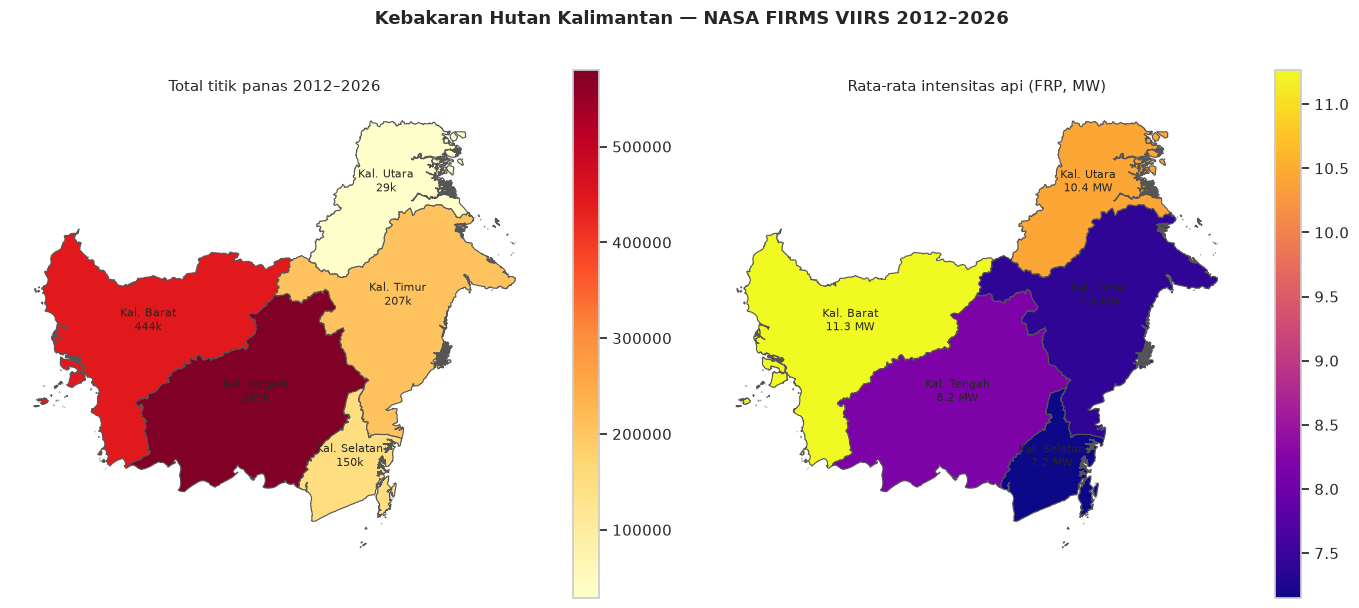

Peta statis tersimpan di outputs/
Peta interaktif tersimpan: /home/shalomputri/karhutla-kalimantan/outputs/peta_interaktif_kalimantan.html
Buka di browser: file:///home/shalomputri/karhutla-kalimantan/outputs/peta_interaktif_kalimantan.html


In [6]:
import folium
import warnings
warnings.filterwarnings("ignore")

# Muat data yang sudah ada label provinsi
firms_prov = pd.read_csv(
    ROOT / "data" / "processed" / "firms_dengan_provinsi.csv"
)

# Agregasi per provinsi: total titik dan rata-rata FRP
rekap = (
    firms_prov.groupby("provinsi")
    .agg(total_titik=("frp","count"), rata_frp=("frp","mean"))
    .reset_index()
)

# Gabung ke shapefile
kal_data = kalimantan.merge(rekap, left_on="NAME_1", right_on="provinsi")

# --- PETA STATIS ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

kal_data.plot(column="total_titik", ax=axes[0], cmap="YlOrRd",
              legend=True, edgecolor="#555", linewidth=0.8)
axes[0].set_title("Total titik panas 2012–2026", fontsize=11)
axes[0].axis("off")
for _, row in kal_data.iterrows():
    c = row.geometry.centroid
    axes[0].annotate(f"{row['NAME_1'].replace('Kalimantan ','Kal. ')}\n{row['total_titik']/1000:.0f}k",
                     xy=(c.x, c.y), ha="center", fontsize=8)

kal_data.plot(column="rata_frp", ax=axes[1], cmap="plasma",
              legend=True, edgecolor="#555", linewidth=0.8)
axes[1].set_title("Rata-rata intensitas api (FRP, MW)", fontsize=11)
axes[1].axis("off")
for _, row in kal_data.iterrows():
    c = row.geometry.centroid
    axes[1].annotate(f"{row['NAME_1'].replace('Kalimantan ','Kal. ')}\n{row['rata_frp']:.1f} MW",
                     xy=(c.x, c.y), ha="center", fontsize=8)

plt.suptitle("Kebakaran Hutan Kalimantan — NASA FIRMS VIIRS 2012–2026",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(ROOT / "outputs" / "peta_statis_kalimantan.png", dpi=150, bbox_inches="tight")
plt.show()

print("Peta statis tersimpan di outputs/")

# --- PETA INTERAKTIF ---
m = folium.Map(location=[-1.5, 114.0], zoom_start=6, tiles="CartoDB positron")

folium.Choropleth(
    geo_data=kal_data.__geo_interface__,
    data=rekap,
    columns=["provinsi", "total_titik"],
    key_on="feature.properties.NAME_1",
    fill_color="YlOrRd",
    fill_opacity=0.7,
    line_opacity=0.5,
    legend_name="Total titik panas 2012–2026",
    highlight=True,
).add_to(m)

# Tooltip per provinsi
for _, row in kal_data.iterrows():
    folium.GeoJson(
        row.geometry.__geo_interface__,
        tooltip=folium.Tooltip(
            f"<b>{row['NAME_1']}</b><br>"
            f"Titik panas: {row['total_titik']:,}<br>"
            f"Rata-rata FRP: {row['rata_frp']:.1f} MW"
        ),
        style_function=lambda x: {"fillOpacity": 0, "color": "transparent"}
    ).add_to(m)

peta_path = ROOT / "outputs" / "peta_interaktif_kalimantan.html"
m.save(str(peta_path))
print(f"Peta interaktif tersimpan: {peta_path}")
print("Buka di browser: file:///home/shalomputri/karhutla-kalimantan/outputs/peta_interaktif_kalimantan.html")

Data latih: 14 tahun

 tahun  titik_panas  frp_mean   luas_ha
  2012       118213 10.778935 374122.00
  2013        73452 12.089767  88836.00
  2014       202166  9.522956 641129.00
  2015       370497  7.854711 957725.17
  2016        41750 10.326781  62898.56
  2017        23277  8.824177  18260.09
  2018        72148  9.864646 243013.50
  2019       183026  8.471139 684599.00
  2020        24795  8.802762  26286.00
  2021        20934  8.244397  37575.00
  2022        17144  7.993134  24562.00
  2023        93804  8.726523 508430.22
  2024        36464  9.655864  65608.11
  2025        37977 10.118796  55717.27

Model                              MAE (ha)   MAPE (%)
------------------------------------------------------
Naive (rata-rata historis)          303,386      547.7
Gradient Boosting (LOO)              85,211       44.1


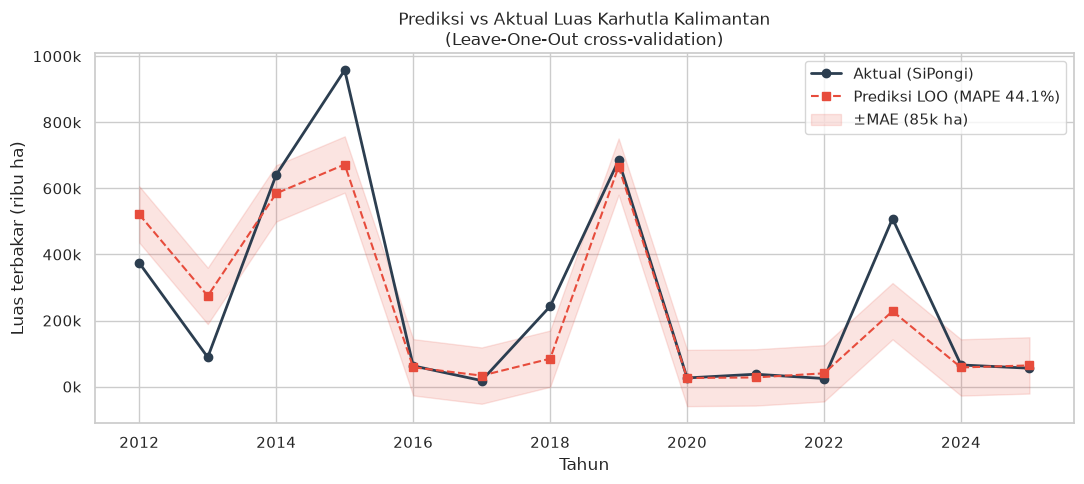


--- Feature importance ---
puncak_bulan    0.639
titik_panas     0.287
frp_mean        0.039
frp_total       0.035


In [7]:
# ============================================================
# MODEL PREDIKSI: Intensitas musim kebakaran per tahun
# ============================================================
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error
import numpy as np

# Fitur tahunan
per_tahun = firms_prov.groupby("tahun").agg(
    titik_panas=("frp","count"),
    frp_total=("frp","sum"),
    frp_mean=("frp","mean"),
    puncak_bulan=("musim", lambda x: (x=="puncak").sum()),
).reset_index()

# Data SiPongi (tanpa 2026 karena belum lengkap)
luas = sipongi[
    (sipongi["tahun_parsial"]==False) &
    (sipongi["tahun"] >= 2012)
].groupby("tahun")["luas_ha"].sum().reset_index()

df_model = per_tahun.merge(luas, on="tahun").dropna()
print(f"Data latih: {len(df_model)} tahun\n")
print(df_model[["tahun","titik_panas","frp_mean","luas_ha"]].to_string(index=False))

# Fitur dan target
FITUR = ["titik_panas","frp_total","frp_mean","puncak_bulan"]
X = df_model[FITUR].values
y = df_model["luas_ha"].values

# Leave-one-out cross validation (data sedikit, LOO lebih jujur)
from sklearn.model_selection import LeaveOneOut

model = GradientBoostingRegressor(
    n_estimators=50, max_depth=2,
    learning_rate=0.1, random_state=42
)

loo = LeaveOneOut()
pred_loo = np.zeros(len(y))
for train_idx, test_idx in loo.split(X):
    model.fit(X[train_idx], y[train_idx])
    pred_loo[test_idx] = model.predict(X[test_idx])

mae = mean_absolute_error(y, pred_loo)
mape = np.mean(np.abs((y - pred_loo) / y)) * 100

# Baseline naive: rata-rata semua tahun sebelumnya
naive = np.array([y[:i].mean() if i > 0 else y[0] for i in range(len(y))])
mae_naive = mean_absolute_error(y, naive)
mape_naive = np.mean(np.abs((y - naive) / y)) * 100

print(f"\n{'Model':<30} {'MAE (ha)':>12} {'MAPE (%)':>10}")
print("-" * 54)
print(f"{'Naive (rata-rata historis)':<30} {mae_naive:>12,.0f} {mape_naive:>10.1f}")
print(f"{'Gradient Boosting (LOO)':<30} {mae:>12,.0f} {mape:>10.1f}")

# Visualisasi prediksi vs aktual
fig, ax = plt.subplots(figsize=(11,5))
ax.plot(df_model["tahun"], y/1000, "o-", color="#2c3e50",
        linewidth=2, label="Aktual (SiPongi)")
ax.plot(df_model["tahun"], pred_loo/1000, "s--", color="#e74c3c",
        linewidth=1.5, label=f"Prediksi LOO (MAPE {mape:.1f}%)")
ax.fill_between(df_model["tahun"],
                (pred_loo - mae)/1000, (pred_loo + mae)/1000,
                alpha=0.15, color="#e74c3c", label=f"±MAE ({mae/1000:.0f}k ha)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x:.0f}k"))
ax.set_xlabel("Tahun")
ax.set_ylabel("Luas terbakar (ribu ha)")
ax.set_title("Prediksi vs Aktual Luas Karhutla Kalimantan\n(Leave-One-Out cross-validation)")
ax.legend()
plt.tight_layout()
plt.savefig(ROOT/"outputs"/"prediksi_luas_karhutla.png", dpi=150, bbox_inches="tight")
plt.show()

# Feature importance
model.fit(X, y)
imp = pd.Series(model.feature_importances_, index=FITUR).sort_values(ascending=False)
print("\n--- Feature importance ---")
print(imp.round(3).to_string())

In [8]:
# Simpan model dan ringkasan untuk dashboard
import pickle

model.fit(X, y)
with open(ROOT/"outputs"/"model_karhutla.pkl","wb") as f:
    pickle.dump({"model":model,"fitur":FITUR,"scaler":None}, f)

# Ringkasan temuan untuk laporan
ringkasan = {
    "total_titik_panas": int(firms_prov["frp"].count()),
    "rentang_tahun": "2012-2026",
    "tahun_terburuk_titik": int(per_tahun.loc[per_tahun["titik_panas"].idxmax(),"tahun"]),
    "tahun_terburuk_luas": int(df_model.loc[df_model["luas_ha"].idxmax(),"tahun"]),
    "provinsi_terparah": "Kalimantan Tengah",
    "mae_model_ha": round(mae),
    "mape_model_pct": round(mape,1),
    "mae_naive_ha": round(mae_naive),
    "fitur_terpenting": "puncak_bulan (63.9%)",
}
import json
with open(ROOT/"outputs"/"ringkasan.json","w") as f:
    json.dump(ringkasan, f, indent=2, ensure_ascii=False)

print(json.dumps(ringkasan, indent=2, ensure_ascii=False))

{
  "total_titik_panas": 1488643,
  "rentang_tahun": "2012-2026",
  "tahun_terburuk_titik": 2015,
  "tahun_terburuk_luas": 2015,
  "provinsi_terparah": "Kalimantan Tengah",
  "mae_model_ha": 85211,
  "mape_model_pct": 44.1,
  "mae_naive_ha": 303386,
  "fitur_terpenting": "puncak_bulan (63.9%)"
}
